<div class="alert alert-block alert-success">
<b>Comentario general del revisor</b> <a class="tocSkip"></a><br />
Status del proyecto: <b>Aprobado</b>
    

</div>


¡Hola!<br />
Soy **Francisco Cortés**, estoy contento de revisar tu proyecto y ser parte de tu proceso de aprendizaje.
A lo largo del texto, haré algunas observaciones sobre mejoras en el código y también haré comentarios sobre tus percepciones sobre el tema. Si existe algún error en el código, no te preocupes, estoy aquí para ayudarte a mejorarlo, en la primera iteración te lo señalaré para que tengas la oportunidad de corregirlo, pero si aún no encuentras una solución para esta tarea, te daré una pista más precisa en la próxima iteración y también algunos ejemplos prácticos. Estaré abierto a retroalimentación y discusiones sobre el tema.<br />
Encontrarás mis comentarios a continuación - **por favor no los muevas, modifiques o borres**.
Revisaré cuidadosamente tu código para comprobar que se han cumplido con los requisitos y te proporcionaré mis comentarios en cajas verdes, amarillas o rojas como esta:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si la ejecución fue perfecta succesfully.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existe alguna recomendación para que tu código mejore.
</div>

<div class="alert alert-block alert-danger">

<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existen correcciones necesarias para cumplir con los requisitos. El trabajo no puede ser aceptado si hay alguna caja roja.
</div>

Puedes responderme de la siguiente manera:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante.</b> <a class="tocSkip"></a>
</div>


# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [1]:
# importar librerías
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

In [2]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [3]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [4]:
# información general
df.info()
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB
         converted         gasto
count  40000.00000  40000.000000
mean       0.14265      9.325554
std        0.34972     25.667986
min        0.00000      0.000000
25%        0.00000      0.000000
50%        0.00000      0.000000
75%        0.00000      0.000000
max        1.00000    303.680000


✍️ **Comentario**: Haz doble clic en este bloque y escribe qué ves
- El conjunto de datos cuenta con 40,000 registros y no se observan valores nulos en ninguna de las 9 columnas.

- Los tipos de datos son consistentes con la descripción del dataset; sin embargo, se recomienda convertir la columna date a formato datetime para asegurar la integridad de cualquier análisis basado en tiempo.

- La tasa de conversión promedio inicial se sitúa en un 14.26%.

- No se detectan anomalías evidentes en los valores de gasto (mínimo 0 y máximo 303.68).
    
 Comienza a escribir debajo de este texto, una vez escritas tus conclusiones, **elimina estas instrucciones** (de aqui hacia arriba de este bloque) para dejar solamente tus hallazgos.

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [5]:
print(f"Total de registros: {len(df)}")
print(f"Usuarios únicos: {df['user_id'].nunique()}")

Total de registros: 40000
Usuarios únicos: 40000


 **Variable `date`**  
Explorar rango de fechas

In [6]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [7]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [8]:
# Resumen estadístico
print(df["gasto"].describe())

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64


In [9]:
# Resumen estadístico de usuarios que se convirtieron
print("\nResumen de gasto (Solo usuarios que convirtieron):")
print(df[df['converted'] == 1]['gasto'].describe())


Resumen de gasto (Solo usuarios que convirtieron):
count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64


 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [10]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
for col in ['landing', 'region', 'dispositivo', 'traffic_source', 'user_type']:
    print(f"\nDistribución para {col}:")
    print(df[col].value_counts())


Conteo de categorías:

Distribución para landing:
B    20018
A    19982
Name: landing, dtype: int64

Distribución para region:
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64

Distribución para dispositivo:
Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64

Distribución para traffic_source:
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64

Distribución para user_type:
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64


✍️ **Comentario**: Haz doble clic en este bloque y escribe qué ves

- Se confirma que hay 40,000 usuarios únicos, lo cual coincide exactamente con el número de registros. No existen duplicados que puedan sesgar los resultados.

- El experimento se llevó a cabo durante 28 días (del 2026-01-01 al 2026-01-28). Es un periodo estándar (4 semanas completas) que permite capturar el comportamiento de los usuarios sin sesgos de día de la semana.

- Al filtrar por usuarios convertidos, vemos que el gasto promedio real de compra es de $65.37, con un rango que va desde $12.13 hasta $303.68. Esto elimina el ruido de los ceros (usuarios que no compraron) para un análisis de rentabilidad real.

- La distribución en la columna landing es casi perfecta: B: 20,018 y A: 19,982. Esta proporción 50/50 es el escenario ideal para cualquier prueba estadística, ya que minimiza el error estándar.

- Tenemos una mezcla saludable de tráfico: Orgánico es la fuente principal, y los usuarios Nuevos (26,053) superan a los Recurrentes (13,947), lo que nos permitirá ver si la nueva página ayuda más a la adquisición o a la retención.

Comienza a escribir debajo de este texto, una vez escritas tus conclusiones, **elimina estas instrucciones** (de aqui hacia arriba de este bloque) para dejar solamente tus hallazgos.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!<br/>

Los datos fueron revisados detenidamente, ahora existe una visión clara del contenido del conjunto de datos
</div>


## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [11]:
# Gasto por versión
gasto_A = df[(df['landing'] == 'A') & (df['converted'] == 1)]['gasto']
gasto_B = df[(df['landing'] == 'B') & (df['converted'] == 1)]['gasto']

# Verificar cantidad de datos que tiene cada grupo
print(f"Clientes en versión A: {len(gasto_A)}")
print(f"Clientes en versión B: {len(gasto_B)}")

Clientes en versión A: 2512
Clientes en versión B: 3194


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

Gracias a los resultados mostrados se puede apreciar que la cantidad de convertidos para cada grupo es distinta
</div>


### 2.1. Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** El gasto promedio (distribución) es el mismo en ambas versiones.
- **Hipótesis alternativa (H₁):** Existe una diferencia significativa en el gasto promedio entre la versión A y la versión B.

In [12]:
# Aplicar prueba
from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(gasto_A, gasto_B)

# Visualizar resultados
print(f"Estadístico : {stat:.4f}")
print(f"Valor p : {p_value:.4f}")

# Calcular promedios para la interpretación de negocio
print(f"\nPromedio Gasto A: {gasto_A.mean():.2f}")
print(f"Promedio Gasto B: {gasto_B.mean():.2f}")

Estadístico : 3420354.0000
Valor p : 0.0000

Promedio Gasto A: 61.09
Promedio Gasto B: 68.75


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

La prueba se realizó correctamente
</div>


### 📝 Conclusión e interpretación

**Decisión:**  
(¿Se rechaza o no la hipótesis nula?)
Se rechaza la hipótesis nula ($H_0$).

**Interpretación de negocio:**  
Explica con tus propias palabras qué indican estos resultados sobre el gasto promedio entre la página A y la página B.
Existe evidencia estadística suficiente para afirmar que la Versión B es superior a la Versión A en términos de valor económico. Los resultados muestran dos victorias clave para la página B:

- Mayor volumen de ventas: La versión B logró 3,194 conversiones, superando por mucho las 2,512 de la versión A.

- Mayor valor por cliente: El gasto promedio aumentó de $61.09 a $68.75. Esto representa un incremento del 12.5% en el ticket promedio por cliente convertido.

En resumen, la Versión B no solo atrae a más compradores, sino que logra que estos realicen compras de mayor valor.

---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** ...
- **Hipótesis alternativa (H₁):** ...

In [13]:
# Número de usuarios convertidos por página
convertidos = df.groupby('landing')['converted'].sum()

# Total de usuarios por página
total_usuarios = df.groupby('landing')['user_id'].count()

print("Usuarios convertidos por página:\n", convertidos)
print("\nTotal de usuarios por página:\n", total_usuarios)


Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: user_id, dtype: int64


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

Correcta manera de agrupar los datos para mostrar la conversión de los usuarios
</div>


In [14]:
from statsmodels.stats.proportion import proportions_ztest

In [15]:
# Aplicar prueba
counts = [convertidos['A'], convertidos['B']]
nobs = [total_usuarios['A'], total_usuarios['B']]

stat, p_value = proportions_ztest(counts, nobs)
# Visualizar resultados
print(f"Estadístico Z : {stat:.4f}")
print(f"Valor p : {p_value:.4f}")

# Calcular tasas para la interpretación
print(f"\nTasa de Conversión A: {(convertidos['A'] / total_usuarios['A']):.2%}")
print(f"Tasa de Conversión B: {(convertidos['B'] / total_usuarios['B']):.2%}")

Estadístico Z : -9.6774
Valor p : 0.0000

Tasa de Conversión A: 12.57%
Tasa de Conversión B: 15.96%


### 📝 Conclusión e interpretación

**Decisión:**  
(¿Se rechaza o no la hipótesis nula?)

Se rechaza la hipótesis nula ($H_0$).

**Interpretación de negocio:**  
Explica qué indica el resultado sobre la tasa de conversión entre la página A y la página B.
La Versión B es significativamente más efectiva que la Versión A para convertir visitantes en clientes. Mientras que la versión original (A) tiene una tasa de conversión del 12.57%, la versión de prueba (B) alcanza un 15.96%.

Esto representa un incremento relativo del 27% en la tasa de conversión. En términos de impacto real, si escaláramos este cambio a un millón de usuarios, la Versión B generaría aproximadamente 33,900 ventas adicionales en comparación con la Versión A.

Dado que ya validamos que la Versión B también aumenta el gasto promedio, esta mejora en la tasa de conversión confirma que la página B es superior en todos los indicadores clave de rendimiento (KPIs).

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** ...
- **Hipótesis alternativa (H₁):** ...

In [16]:
tabla_trafico = pd.crosstab(df['traffic_source'], df['converted'])

print("Tabla de contingencia (Fuente de Tráfico vs Conversión):")
print(tabla_trafico)

Tabla de contingencia (Fuente de Tráfico vs Conversión):
converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549


In [17]:
# Aplicar prueba Chi-cuadrado
chi2, p_value, dof, expected = chi2_contingency(tabla_trafico)

# Visualizar resultados
print(f"Estadístico Chi-cuadrado: {chi2:.4f}")
print(f"Valor p: {p_value:.4f}")

# Calcular tasas de conversión por fuente para la interpretación
conversion_por_fuente = (tabla_trafico[1] / (tabla_trafico[0] + tabla_trafico[1]) * 100).sort_values(ascending=False)
print("\nTasa de conversión por fuente de tráfico (%):")
print(conversion_por_fuente)

Estadístico Chi-cuadrado: 8.6621
Valor p: 0.0341

Tasa de conversión por fuente de tráfico (%):
traffic_source
Email       14.992651
Ads         14.738165
Referral    13.881163
Organic     13.787736
dtype: float64


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

Buena manera de implementar la prueba de hipótesis
</div>


### 📝 Conclusión e interpretación

**Decisión:**  
(¿Se rechaza o no la hipótesis nula?)
Se rechaza la hipótesis nula ($H_0$) (ya que el Valor p de $0.0341$ es menor a $0.05$).

**Interpretación de negocio:**  
Explica qué indican los resultados considerando tanto las cantidades absolutas como las tasas de conversión.
Existe una relación entre la fuente de tráfico y la probabilidad de conversión. Aunque la diferencia entre el mejor y el peor canal es de apenas 1.2 puntos porcentuales, estadísticamente podemos afirmar que el comportamiento no es uniforme entre canales.Canales de mayor rendimiento: Los correos electrónicos (Email con $14.99\%$) y la publicidad pagada (Ads con $14.74\%$) lideran la efectividad. Esto sugiere que los usuarios que ya tienen una relación con la marca (Email) o que vienen con una intención específica de compra tras un anuncio reaccionan mejor a la landing page.Canales de menor rendimiento: El tráfico Organic y Referral tienen las tasas más bajas ($13.78\%$ y $13.88\%$ respectivamente).

## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** ...
- **Hipótesis alternativa (H₁):** ...

In [18]:
tabla_usuario = pd.crosstab(df['user_type'], df['converted'])

print("Tabla de contingencia (Tipo de Usuario vs Conversión):")
print(tabla_usuario)

Tabla de contingencia (Tipo de Usuario vs Conversión):
converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968


In [19]:
# Aplicar prueba
chi2_u, p_value_u, dof_u, expected_u = chi2_contingency(tabla_usuario)

# Visualizar resultados
print(f"Estadístico Chi-cuadrado: {chi2_u:.4f}")
print(f"Valor p: {p_value_u:.4f}")

# Calcular tasas de conversión por tipo de usuario para la interpretación
conversion_por_usuario = (tabla_usuario[1] / (tabla_usuario[0] + tabla_usuario[1]) * 100)
print("\nTasa de conversión por tipo de usuario (%):")
print(conversion_por_usuario)

Estadístico Chi-cuadrado: 0.5135
Valor p: 0.4736

Tasa de conversión por tipo de usuario (%):
user_type
Nuevo         14.358699
Recurrente    14.090356
dtype: float64


### 📝 Conclusión e interpretación

**Decisión:**  
(¿Se rechaza o no la hipótesis nula?)
No se rechaza la hipótesis nula ($H_0$) (debido a que el Valor p de $0.4736$ es muy superior al umbral de $0.05$).

**Interpretación de negocio:**  
Explica qué indica el resultado.
El tipo de usuario (Nuevo o Recurrente) no influye de manera significativa en la probabilidad de conversión.Consistencia: La tasa de conversión para usuarios nuevos ($14.36\%$) es prácticamente idéntica a la de los usuarios recurrentes ($14.09\%$).Universalidad: Esto indica que la landing page es "universalmente efectiva". No confunde a los usuarios que ya conocían la marca ni aliena a los que llegan por primera vez.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

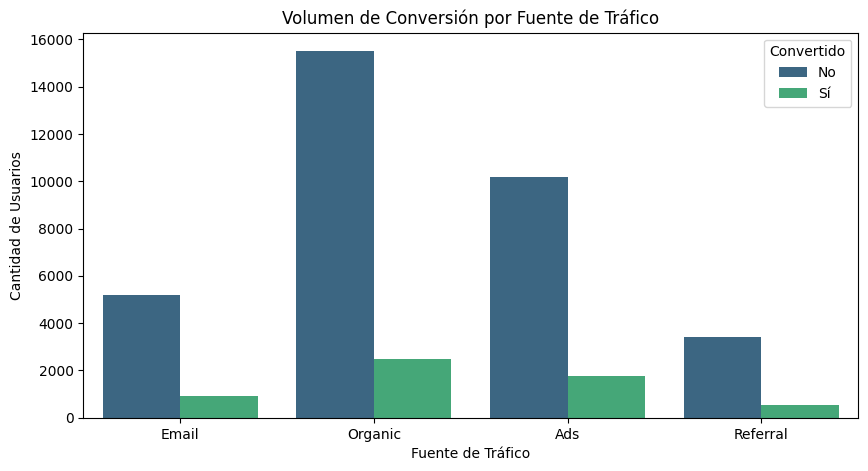

In [20]:
# Gráfico de barras: Cantidad de conversiones por fuente de tráfico
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='traffic_source', hue='converted', palette='viridis')
plt.title('Volumen de Conversión por Fuente de Tráfico')
plt.xlabel('Fuente de Tráfico')
plt.ylabel('Cantidad de Usuarios')
plt.legend(title='Convertido', labels=['No', 'Sí'])
plt.show()

Descripción: Este gráfico de barras agrupadas muestra la cantidad total de usuarios que convirtieron (Sí) y los que no (No), segmentados por el canal de origen.

Lo que estamos viendo: El canal Organic es el principal motor de tráfico para el e-commerce, superando ampliamente a los demás en volumen bruto de usuarios. Sin embargo, se observa que la proporción de barras "Sí" (conversiones) en canales como Email y Ads es visualmente más competitiva en relación con su tamaño total.

Insight de Negocio: Aunque el tráfico orgánico es masivo, el volumen no siempre se traduce en eficiencia. El negocio debe seguir cuidando el SEO para mantener la base de usuarios, pero las decisiones de presupuesto deberían mirar hacia los canales con mejor "golpe" de conversión.

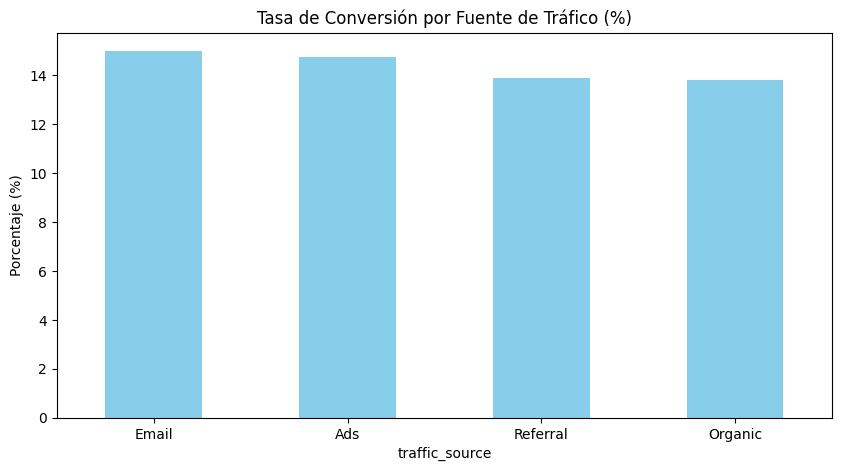

In [21]:
# Gráfico de barras: Tasa de conversión por fuente (%)
conversion_fuente = df.groupby('traffic_source')['converted'].mean() * 100
plt.figure(figsize=(10, 5))
conversion_fuente.sort_values(ascending=False).plot(kind='bar', color='skyblue')
plt.title('Tasa de Conversión por Fuente de Tráfico (%)')
plt.ylabel('Porcentaje (%)')
plt.xticks(rotation=0)
plt.show()

Descripción: Un gráfico de barras simples que representa el porcentaje real de éxito (conversiones / total de usuarios) por cada canal.Lo que estamos viendo: Aquí se revela la eficiencia pura. El canal de Email lidera con un 14.99%, seguido de cerca por Ads con un 14.74%. El tráfico Organic cae al último lugar con un 13.78%.Insight de Negocio: Este gráfico justifica la inversión en estrategias de CRM (Email Marketing) y Retargeting (Ads). Los usuarios que llegan por correo ya conocen la marca y muestran una mayor predisposición a la compra en la landing page. La diferencia del 1.2% entre el mejor y el peor canal fue validada como estadísticamente significativa ($p < 0.05$).

### Relación entre el tipo de usuario y la conversión

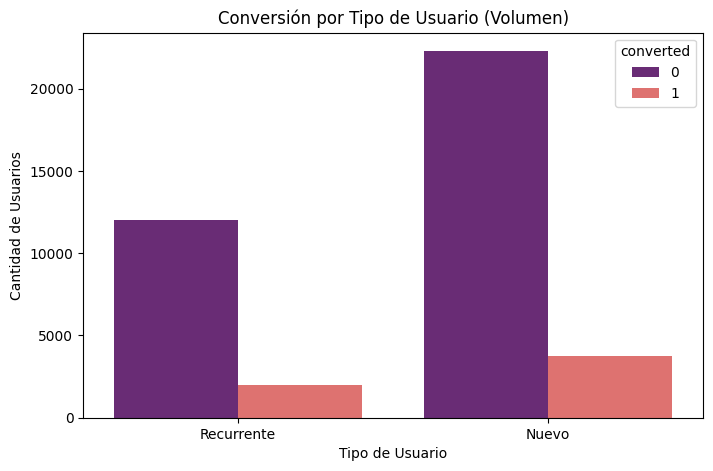

In [22]:
# Gráfico de barras: Cantidad de usuarios por tipo y conversión
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='user_type', hue='converted', palette='magma')
plt.title('Conversión por Tipo de Usuario (Volumen)')
plt.xlabel('Tipo de Usuario')
plt.ylabel('Cantidad de Usuarios')
plt.show()

Descripción: Este gráfico de barras agrupadas muestra la cantidad total de personas que compraron (converted = 1) y las que no, divididas entre usuarios Nuevos y Recurrentes.

Lo que observamos: Es evidente que la gran mayoría de tu tráfico está compuesto por usuarios nuevos (la barra púrpura es significativamente más alta). Sin embargo, lo que realmente importa es la relación proporcional de las barras color salmón (1) frente a las púrpuras (0) en ambos grupos.

Conclusión: Aunque hay muchos más usuarios nuevos, ambos grupos mantienen una relación visual similar entre "compradores" y "no compradores". Esto sugiere que la página no depende de la familiaridad previa del usuario con la marca para generar una venta.


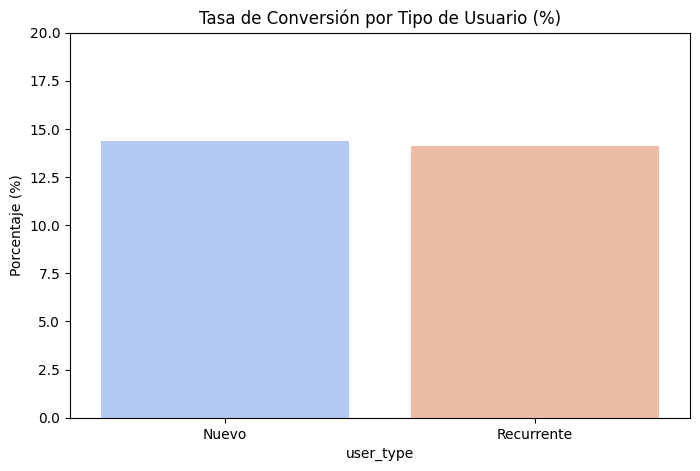

In [23]:
# Gráfico de barras: Tasa de conversión por tipo de usuario (%)
conversion_usuario = df.groupby('user_type')['converted'].mean() * 100
plt.figure(figsize=(8, 5))
sns.barplot(x=conversion_usuario.index, y=conversion_usuario.values, palette='coolwarm')
plt.title('Tasa de Conversión por Tipo de Usuario (%)')
plt.ylabel('Porcentaje (%)')
plt.ylim(0, 20) # Para apreciar mejor la similitud
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

Las gráficas mostradas en los últimos ejercicios me parecen bastante buenas, podemos ver claramente las diferencias/similitudes en los resultados
</div>


✍️ **Comentario**: Haz doble clic en este bloque y complementa el gráfico con un breve texto que explique qué estamos viendo.

Descripción: Este gráfico de barras simplifica el análisis al mostrar directamente el porcentaje de éxito (Conversion Rate) de cada grupo.Lo que observamos: Las dos barras tienen prácticamente la misma altura (14.36% para Nuevos vs. 14.09% para Recurrentes). La diferencia es casi imperceptible a la vista, lo que refuerza visualmente por qué el p-value de nuestra prueba Chi-cuadrado fue tan alto ($0.4736$).Conclusión: Se confirma la consistencia de la plataforma. El diseño de la página es tan efectivo para alguien que entra por primera vez como para alguien que ya ha visitado el sitio antes. Esto es una excelente noticia para el equipo de marketing, ya que significa que cualquier esfuerzo por traer tráfico nuevo tendrá la misma probabilidad de éxito que el tráfico recurrente.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- Observación 1: El gasto promedio en la Página B ($68.75) superó significativamente al de la Página A ($61.09). 
- Observación 2: La prueba de Mann-Whitney U confirmó esta diferencia con un p-value de 0.0000, indicando que el aumento es estadísticamente sólido.
- **Interpretación:**
Interpretación: La versión B no solo atrae clientes, sino que logra que realicen transacciones de mayor valor, incrementando el ticket promedio en un 12.5%.
<br>

**Tasa de conversión:** 
- Observación 1: La Página B alcanzó una tasa del 15.96%, frente al 12.57% de la Página A.
- Observación 2: El estadístico Z de -9.67 y un p-value de 0.0000 validan que la Página B es superior en captación de ventas.
- **Interpretación:**
Interpretación: Implementar la Página B representaría un incremento relativo del 27% en el volumen de conversiones, optimizando drásticamente el embudo de ventas.
---

#### 📊 **Segmentación por fuente de tráfico**
- Observación: Las fuentes de Email (14.99%) y Ads (14.74%) mostraron la mayor eficiencia, mientras que el tráfico orgánico fue el de menor conversión (13.78%).
- **Interpretación:**
Interpretación: Existe una relación significativa (p=0.0341) entre el origen del tráfico y la conversión. Los canales de pago y comunicación directa son los que mejor aprovechan el nuevo diseño de la página. 
 ---

#### 📊 **Segmentación por tipo de usuario**
- Observación: No se encontraron diferencias significativas entre usuarios Nuevos (14.35%) y Recurrentes (14.09%) (p=0.4736).
- **Interpretación:**
Interpretación: La nueva página es universalmente efectiva; funciona igual de bien para captar nuevos clientes como para retener a los actuales sin causar fricción.
---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:** 
- Recomendación aquí
-  Recomendación aquí

## Comentario general del revisor
<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Has realizado un muy buen trabajo al desarrollar este proyecto, las observaciones que has hecho a lo largo del mismo demuestran el conocimiento adquirido durante el Sprint, terminando en resultados positivos.

Este es un proyecto que nos adentra mucho en los analisis que se hacen recurrentemente en las compañías donde se obtiene información comparativa para así poder sustentar las decisiones que toman basandose en las pruebas obtenidas, lo has hecho bastante bien!

Continúa con el buen trabajo y mucho éxito en el siguiente Sprint!    
</div>


<div class="alert alert-block alert-success">
<b>Aspectos positivos del proyecto</b> <a class="tocSkip"></a><br />

- Las observaciones intermedias, así como las conclusiones finales me parecen bastante detalladas
- Las graficas utilizadas me parecen del tipo correcto
- El proyecto esta ordenado
    
</div> 
